# 2D+1 CWT for multiple time steps
Loop over multiple time steps and compute the 2D CWT plus the XWT. Parallelize that in a next step.

In [1]:
import sys
sys.path.append("/home/r/Robert.Reichert/juwavelet")
import juwavelet.transform as transform
from juwavelet import utils
sys.path.append('../scripts')
import utils_2d_v3 as two
import utils_3d as three
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("../latex_default_AMT.mplstyle")

In [2]:
data_path = '../data/AMTM_recon_fast.nc'
ds_fast = xr.open_dataset(data_path)
signal = ds_fast['BI_recon'].values

/home/r/Robert.Reichert/.conda/envs/JuWavelet/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [4]:
data_path = '../data/AMTM_recon_KHI.nc'
ds_KHI = xr.open_dataset(data_path)
signal = ds_KHI['BI_recon'].values

In [2]:
data_path = '../data/AMTM_recon_strong.nc'
ds_strong = xr.open_dataset(data_path)
signal = ds_strong['BI_recon'].values

/home/r/Robert.Reichert/.conda/envs/JuWavelet/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
data_path = '../data/AMTM_recon_noise.nc'
ds_noise = xr.open_dataset(data_path)
signal = ds_noise['BI_recon'].values

/home/r/Robert.Reichert/.conda/envs/JuWavelet/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
data_path = '../data/AMTM_recon_big.nc'
ds_big = xr.open_dataset(data_path)
signal = ds_big['BI_recon'].values

/home/r/Robert.Reichert/.conda/envs/JuWavelet/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [3]:
dx, dy, dt = 625, 625, 35
ny, nx, nt = signal.shape
s0 = 4
s1 = 0.5 * min([nx,ny])
dj = 1/4
js = int(1/dj*np.log2(s1/s0))
jt = 15

cwt_result = transform.decompose2d(signal[:,:,100].T,dx,dy,s0*min([dx,dy]),dj,js,jt,aspect=1,
    nxpad=None,nypad=None,opts={'param': 2*np.pi},
    mode="scaled",dtype=np.complex128)

print(f"The data resolution is {dx*1e-3:.3f} km and the smallest wavelength you analyze is {cwt_result['period'][0]*1e-3:.3f} km.")
print(f"The data domain is at least {min([nx,ny])*dx*1e-3:.0f} km and the largest wavelength you analyze is {cwt_result['period'][-1]*1e-3:.0f} km.")

/home/r/Robert.Reichert/juwavelet/juwavelet/transform.py:324: RuntimeWarning: divide by zero encountered in divide
  wys = periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :]))


The data resolution is 0.625 km and the smallest wavelength you analyze is 2.500 km.
The data domain is at least 133 km and the largest wavelength you analyze is 48 km.


/home/r/Robert.Reichert/juwavelet/juwavelet/transform.py:367: RuntimeWarning: divide by zero encountered in divide
  "wavelength_y": periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :])),


In [4]:
x = np.linspace(0,(nx-1)*dx,nx)
y = np.linspace(0,(ny-1)*dy,ny)
t = np.linspace(0,(nt-1)*dt,nt)

cwt_dummy = transform.decompose2d(signal[:,:,0].T,dx,dy,s0*min([dx,dy]),dj,js,jt,aspect=1,
    nxpad=None,nypad=None,opts={'param': 2*np.pi},
    mode="scaled",dtype=np.complex128)

shape = (cwt_dummy['decomposition'].shape[0],cwt_dummy['decomposition'].shape[1],cwt_dummy['decomposition'].shape[2],cwt_dummy['decomposition'].shape[3],nt)
cwt_real = np.zeros(shape)
cwt_imag = np.zeros(shape)

for step in range(nt):
    
    print(f'{step/nt*100:.0f}%')
    
    cwt_result = transform.decompose2d(signal[:,:,step].T,dx,dy,s0*min([dx,dy]),dj,js,jt,aspect=1,
        nxpad=None,nypad=None,opts={'param': 2*np.pi},
        mode="scaled",dtype=np.complex128)

    cwt_real[:,:,:,:,step] = np.real(cwt_result['decomposition'])
    cwt_imag[:,:,:,:,step] = np.imag(cwt_result['decomposition'])
    
ds = xr.Dataset(
    {
        "decomposition_real": xr.DataArray(cwt_real,
            dims=("period", "theta", "x", "y", "time"),
            coords={"x": x, "y": y, "time": t, "period": cwt_result['period'], "theta": cwt_result['theta']},
        ),
        "decomposition_imag": xr.DataArray(cwt_imag,
            dims=("period", "theta", "x", "y", "time"),
            coords={"x": x, "y": y, "time": t, "period": cwt_result['period'], "theta": cwt_result['theta']},
        ),
    },
    attrs={
        'title': '2D Continuous Wavelet Transform',
        'instrument_name': 'Advanced Mesospheric Temperature Mapper',
        'location': 'Río Grande',
        'temporal_resolution': dt,
        'horizontal_resolution': dx,
        'dj': cwt_result['dj'],
        'js': cwt_result['js'],
        'jt': cwt_result['jt'],
        'dx': cwt_result['dx'],
        'dy': cwt_result['dy'],
        'scale': cwt_result['scale'],
        'aspect': cwt_result['aspect'],
        'mode': cwt_result['mode'],
        'param': cwt_result['opts']['param'],
        'contact_data_analysis': 'robert.reichert@physik.uni-muenchen.de',
        'contact_raw_datag': 'dominiquepautet@gmail.com',
        'history': f'Created on {pd.Timestamp.now()}',
        'references': 'Pautet et al. (2014)',
        'comment': '',
        'file_creator_name': 'Dr. Robert Reichert',
    },
)

#ds.to_netcdf(path="../data/XWT_KHI.nc")

0%
1%
1%
2%
3%
3%
4%
5%
5%
6%
6%
7%
8%
8%
9%
10%
10%
11%
12%
12%
13%
14%
14%
15%
15%
16%
17%
17%
18%
19%
19%
20%
21%
21%
22%
23%
23%
24%
25%
25%
26%
26%
27%
28%
28%
29%
30%
30%
31%
32%
32%
33%
34%
34%
35%
35%
36%
37%
37%
38%
39%
39%
40%
41%
41%
42%
43%
43%
44%
45%
45%
46%
46%
47%
48%
48%
49%
50%
50%
51%
52%
52%
53%
54%
54%
55%
55%
56%
57%
57%
58%
59%
59%
60%
61%
61%
62%
63%
63%
64%
65%
65%
66%
66%
67%
68%
68%
69%
70%
70%
71%
72%
72%
73%
74%
74%
75%
75%
76%
77%
77%
78%
79%
79%
80%
81%
81%
82%
83%
83%
84%
85%
85%
86%
86%
87%
88%
88%
89%
90%
90%
91%
92%
92%
93%
94%
94%
95%
95%
96%
97%
97%
98%
99%
99%


In [5]:
XWT_real = np.zeros_like(ds['decomposition_real'].values)
XWT_imag = np.zeros_like(ds['decomposition_imag'].values)

for i, step in enumerate(ds.time.isel(time=slice(0,-1))):
    
    XWT_real[:,:,:,:,i] = ds['decomposition_real'].isel(time=i)*ds['decomposition_real'].isel(time=i+1)+ds['decomposition_imag'].isel(time=i)*ds['decomposition_imag'].isel(time=i+1)  
    XWT_imag[:,:,:,:,i] = ds['decomposition_imag'].isel(time=i)*ds['decomposition_real'].isel(time=i+1)-ds['decomposition_real'].isel(time=i)*ds['decomposition_imag'].isel(time=i+1)

XWT_real_xr = xr.DataArray(
    XWT_real,
    dims=("period", "theta", "x", "y", "time"),
    coords={"x": ds['x'].values, "y": ds['y'].values, "time": ds['time'], "period": ds['period'], "theta": ds['theta']},
    )
XWT_imag_xr = xr.DataArray(
    XWT_imag,
    dims=("period", "theta", "x", "y", "time"),
    coords={"x": ds['x'].values, "y": ds['y'].values, "time": ds['time'], "scale": ds['period'], "theta": ds['theta']},
    )

ds['XWT_real'] = XWT_real_xr
ds['XWT_imag'] = XWT_imag_xr

In [6]:
WP_amp = []
WP_kx = []
WP_ky = []
WP_om = []
#nt=150
for time_index in range(nt):
    xwt_dict = {'decomposition': ds['XWT_real'].isel(time=time_index).values+1j*ds['XWT_imag'].isel(time=time_index).values, 'period': ds['period'], 'theta': ds['theta']}
    A, kx, ky, om = three.A_kx_ky_kz(xwt_dict,dt)

    mask = A>80
    if np.sum(mask) == 0:
        WP_amp = np.append(WP_amp,np.nan)
        WP_kx = np.append(WP_kx,np.nan)
        WP_ky = np.append(WP_ky,np.nan)
        WP_om = np.append(WP_om,np.nan)
    elif np.sum(mask) > 0:
        WP_amp = np.append(WP_amp,np.mean(A[mask]))
        WP_kx = np.append(WP_kx,np.average(kx[mask],weights=A[mask]))
        WP_ky = np.append(WP_ky,np.average(ky[mask],weights=A[mask]))
        WP_om = np.append(WP_om,np.average(om[mask],weights=A[mask]))

WP_lh, WP_th = two.kxky_2_lhtheta(WP_kx,WP_ky)
WP_c=WP_lh*WP_om/2/np.pi

100%|██████████| 51759/51759 [00:01<00:00, 37577.93it/s]


In [7]:
ds = xr.Dataset(
    {
        "amplitude": xr.DataArray(WP_amp,
            dims=("time"),
            coords={"time": ds_big.time.values},
        ),
        "wavelength": xr.DataArray(WP_lh,
            dims=("time"),
            coords={"time": ds_big.time.values},
        ),
        "frequency": xr.DataArray(WP_om,
            dims=("time"),
            coords={"time": ds_big.time.values},
        ),
        "orientation": xr.DataArray(WP_th,
            dims=("time"),
            coords={"time": ds_big.time.values},
        ),
    }
)

ds.to_netcdf(path="../data/big_WP_properties.nc")

Text(0, 0.5, 'Phase speed / ms$^{-1}$')

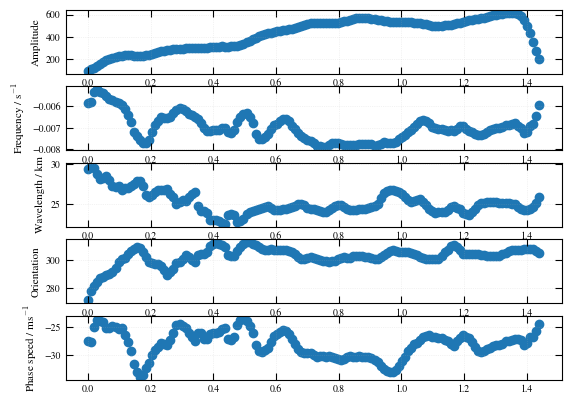

In [10]:
#WP_lh, WP_th = two.kxky_2_lhtheta(WP_kx,WP_ky)
#WP_c=WP_lh*WP_om/2/np.pi

fig=plt.figure()
ax=fig.add_subplot(511)
ax.scatter(np.linspace(0,(nt-1)*dt/3600,nt),WP_amp)
ax.set_ylabel('Amplitude')
ax=fig.add_subplot(512)
ax.scatter(np.linspace(0,(nt-1)*dt/3600,nt),WP_om)
ax.set_ylabel('Frequency / s$^{-1}$')
ax=fig.add_subplot(513)
ax.scatter(np.linspace(0,(nt-1)*dt/3600,nt),WP_lh*1e-3)
ax.set_ylabel('Wavelength / km')
ax=fig.add_subplot(514)
ax.scatter(np.linspace(0,(nt-1)*dt/3600,nt),np.rad2deg(WP_th))
ax.set_ylabel('Orientation')
ax=fig.add_subplot(515)
ax.scatter(np.linspace(0,(nt-1)*dt/3600,nt),WP_c)
ax.set_ylabel('Phase speed / ms$^{-1}$')

Text(0, 0.5, 'Phase speed / ms$^{-1}$')

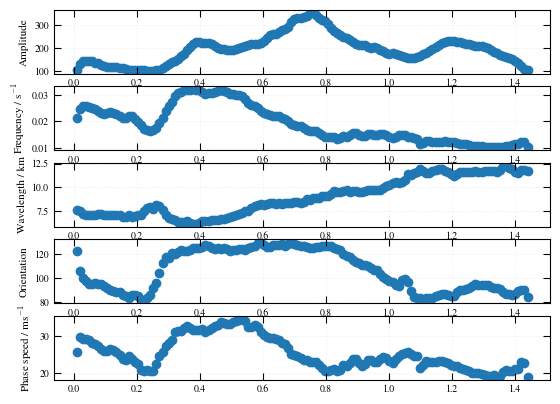

In [29]:
WP_lh, WP_th = two.kxky_2_lhtheta(WP_kx,WP_ky)
WP_c=WP_lh*WP_om/2/np.pi

fig=plt.figure()
ax=fig.add_subplot(511)
ax.scatter(np.linspace(0,(nt-1)*dt/3600,nt),KHI_amp)
ax.set_ylabel('Amplitude')
ax=fig.add_subplot(512)
ax.scatter(np.linspace(0,(nt-1)*dt/3600,nt),KHI_om)
ax.set_ylabel('Frequency / s$^{-1}$')
ax=fig.add_subplot(513)
ax.scatter(np.linspace(0,(nt-1)*dt/3600,nt),KHI_lh*1e-3)
ax.set_ylabel('Wavelength / km')
ax=fig.add_subplot(514)
ax.scatter(np.linspace(0,(nt-1)*dt/3600,nt),np.rad2deg(KHI_th))
ax.set_ylabel('Orientation')
ax=fig.add_subplot(515)
ax.scatter(np.linspace(0,(nt-1)*dt/3600,nt),KHI_c)
ax.set_ylabel('Phase speed / ms$^{-1}$')

<>:61: SyntaxWarning: invalid escape sequence '\c'
<>:61: SyntaxWarning: invalid escape sequence '\c'
/scratch-local/slurm-job-tmp-14299915/ipykernel_3494/1188758568.py:61: SyntaxWarning: invalid escape sequence '\c'
  cbar.ax.set_xticklabels(['0$^{\circ}$','90$^{\circ}$','180$^{\circ}$','270$^{\circ}$','360$^{\circ}$'])


53.333333333333336


100%|██████████| 51759/51759 [00:01<00:00, 33532.07it/s]


'\nplot_signal = ax[1,1].contourf(y,x,signal[:,:,time_index].T,cmap=royal,levels=BI_lev,extend=\'both\')\nax[1,1].tick_params(which=\'both\', labelleft=False)\ncbar = fig.colorbar(plot_signal, ax=ax[0,1], location=\'top\', ticks=[-2000,-1000,0,1000,2000], fraction=1, shrink=0.9, extend=\'both\',label=\'BI perturbation\', aspect=25)\n#ax[1,1].quiver(Y[::step,::step],X[::step,::step],c[::step,::step]*np.sin(th[::step,::step]),c[::step,::step]*np.cos(th[::step,::step]),c[::step,::step],cmap=\'Reds\',scale=3000,width=0.004,clim=(0,50))\nax[1,1].grid()\n\nplot_lh = ax[1,2].contourf(y,x,lh*1e-3,cmap=\'plasma\',levels=cwt_result[\'period\'][cwt_result[\'period\']<50_000]*1e-3,extend=\'max\')\nax[1,2].tick_params(which=\'both\', labelleft=False, labelright=True)\ncbar = fig.colorbar(plot_lh, ax=ax[0,2], location=\'top\', ticks=[2.5,5,10,20,50], fraction=1, shrink=0.9, extend=\'both\',label=\'Wavelength / km\', aspect=25)\nax[1,2].grid()\n\nplot_om = ax[2,0].contourf(y,x,np.abs(om),cmap=\'plasm

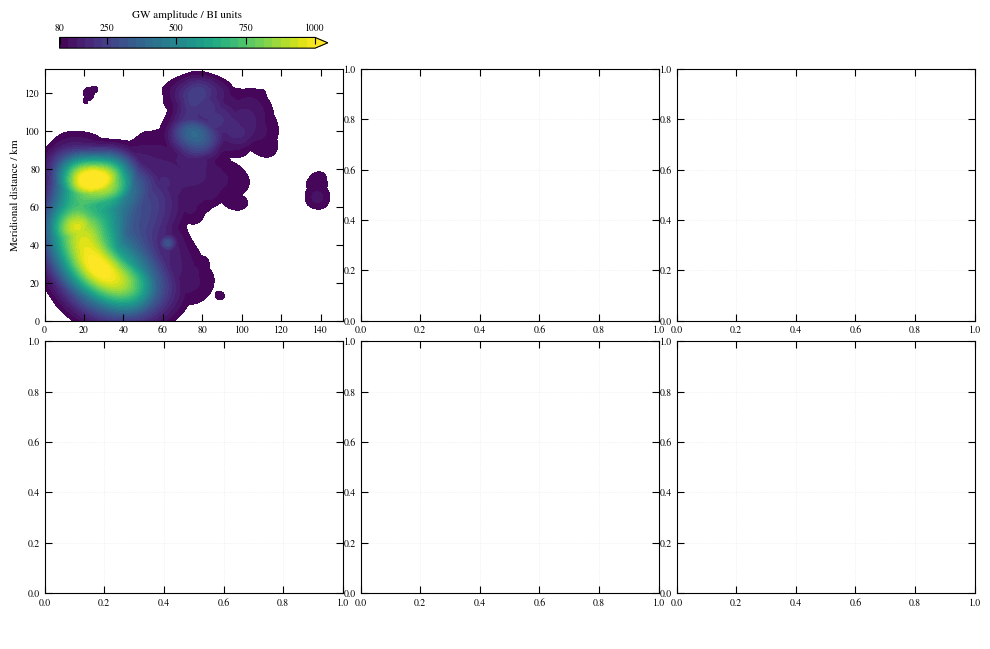

In [9]:
# MEDIUM SCALE WAVES 

gskw = {"hspace": 0.15, "wspace": 0.06, "width_ratios": [1, 1, 1], "height_ratios": [0.1, 1, 1, 0.1]}
#royal=get_cmap().reversed()
BI_lev=np.linspace(-2000,2000,31)

x = np.linspace(0,(nx-1)*dx,nx)*1e-3
y = np.linspace(0,(ny-1)*dy,ny)*1e-3
Y, X = np.meshgrid(y,x)
step=10

xlab = ['','','','Zonal distance / km','Zonal distance / km','Zonal distance / km']
ylab = ['Meridional distande / km','','','Meridional distance','','']

#for time_index in range(nt):
time_index=80
print(time_index/nt*100)
xwt_dict = {'decomposition': ds['XWT_real'].isel(time=time_index).values+1j*ds['XWT_imag'].isel(time=time_index).values, 'period': ds['period'], 'theta': ds['theta']}
A, kx, ky, om = three.A_kx_ky_kz(xwt_dict,dt)
lh, th = two.kxky_2_lhtheta(kx,ky)

th[A<80]=np.nan
lh[A<80]=np.nan
om[A<80]=np.nan
c=lh*np.abs(om)/2/np.pi

fig, ax=plt.subplots(4,3, figsize=(12,8), gridspec_kw=gskw)
ax[0,0].axis('off')
ax[0,1].axis('off')
ax[0,2].axis('off')
ax[3,0].axis('off')
ax[3,1].axis('off')
ax[3,2].axis('off')


plot_amp = ax[1,0].contourf(y,x,A,cmap='viridis',levels=np.linspace(80,1000,31),extend='max')
cbar = fig.colorbar(plot_amp, ax=ax[0,0], location='top', ticks=[80,250,500,750,1000], fraction=1, shrink=0.9, extend='both',label='GW amplitude / BI units', aspect=25)
ax[1,0].set_ylabel('Meridional distance / km')
ax[1,0].grid()

"""
plot_signal = ax[1,1].contourf(y,x,signal[:,:,time_index].T,cmap=royal,levels=BI_lev,extend='both')
ax[1,1].tick_params(which='both', labelleft=False)
cbar = fig.colorbar(plot_signal, ax=ax[0,1], location='top', ticks=[-2000,-1000,0,1000,2000], fraction=1, shrink=0.9, extend='both',label='BI perturbation', aspect=25)
#ax[1,1].quiver(Y[::step,::step],X[::step,::step],c[::step,::step]*np.sin(th[::step,::step]),c[::step,::step]*np.cos(th[::step,::step]),c[::step,::step],cmap='Reds',scale=3000,width=0.004,clim=(0,50))
ax[1,1].grid()

plot_lh = ax[1,2].contourf(y,x,lh*1e-3,cmap='plasma',levels=cwt_result['period'][cwt_result['period']<50_000]*1e-3,extend='max')
ax[1,2].tick_params(which='both', labelleft=False, labelright=True)
cbar = fig.colorbar(plot_lh, ax=ax[0,2], location='top', ticks=[2.5,5,10,20,50], fraction=1, shrink=0.9, extend='both',label='Wavelength / km', aspect=25)
ax[1,2].grid()

plot_om = ax[2,0].contourf(y,x,np.abs(om),cmap='plasma',levels=np.linspace(0,0.03,31),extend='max')
ax[2,0].tick_params(which='both', labelbottom=False)
cbar = fig.colorbar(plot_om, ax=ax[3,0], location='bottom', ticks=[0,0.01,0.02,0.03], fraction=1, shrink=0.9, extend='both',label='Observed frequency / s$^{-1}$', aspect=25)
ax[2,0].set_ylabel('Meridional distance / km')
ax[2,0].grid()

plot_th = ax[2,1].contourf(y,x,th,cmap='twilight',levels=np.linspace(0,2*np.pi,30))
cbar = fig.colorbar(plot_th, ax=ax[3,1], location='bottom', ticks=[0,np.pi/2,np.pi,3/2*np.pi,2*np.pi], fraction=1, shrink=0.9, extend='both',label='Propagation direction', aspect=25)
cbar.ax.set_xticklabels(['0$^{\circ}$','90$^{\circ}$','180$^{\circ}$','270$^{\circ}$','360$^{\circ}$'])

ax[2,1].quiver(Y[::step,::step],X[::step,::step],c[::step,::step]*np.sin(th[::step,::step]),c[::step,::step]*np.cos(th[::step,::step]))
ax[2,1].tick_params(which='both', labelbottom=False, labelleft=False)
ax[2,1].grid()

plot_c = ax[2,2].contourf(y,x,c,cmap='Reds',levels=np.linspace(0,50,51),extend='max')
cbar = fig.colorbar(plot_c, ax=ax[3,2], location='bottom', ticks=[0,10,20,30,40,50], fraction=1, shrink=0.9, extend='both',label='Phase speed / ms$^{-1}$', aspect=25)
ax[2,2].tick_params(which='both', labelbottom=False, labelleft=False, labelright=True)
ax[2,2].grid()

#ax[1,1].text(0.97, 0.95, str(BI['time'].isel(time=t).values)[11:19]+'UTC', verticalalignment='center', horizontalalignment='right', transform=ax[1,1].transAxes, 
#                                weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

plt.savefig('./medium_wave/gary_'+str(time_index).zfill(3)+'.png', dpi=120, facecolor="w", edgecolor="w")#, bbox_inches="tight")
plt.close()
"""

In [7]:
# SMALL SCALE WAVES 

gskw = {"hspace": 0.15, "wspace": 0.06, "width_ratios": [1, 1, 1], "height_ratios": [0.1, 1, 1, 0.1]}
royal=get_cmap().reversed()
BI_lev=np.linspace(-2000,2000,31)

x = np.linspace(0,(nx-1)*dx,nx)*1e-3
y = np.linspace(0,(ny-1)*dy,ny)*1e-3
Y, X = np.meshgrid(y,x)
step=10

xlab = ['','','','Zonal distance / km','Zonal distance / km','Zonal distance / km']
ylab = ['Meridional distande / km','','','Meridional distance','','']

for time_index in range(nt):
#time_index=40
    print(time_index/nt*100)
    xwt_dict = {'decomposition': ds['XWT_real'].isel(time=time_index).values+1j*ds['XWT_imag'].isel(time=time_index).values, 'period': ds['period'], 'theta': ds['theta']}
    A, kx, ky, om = wfp.A_kx_ky_kz(xwt_dict,dt)
    lh, th = wfp.kxky_2_lhtheta(kx,ky)
    
    th[A<80]=np.nan
    lh[A<80]=np.nan
    om[A<80]=np.nan
    c=lh*om/2/np.pi
    
    fig, ax=plt.subplots(4,3, figsize=(12,8), gridspec_kw=gskw)
    ax[0,0].axis('off')
    ax[0,1].axis('off')
    ax[0,2].axis('off')
    ax[3,0].axis('off')
    ax[3,1].axis('off')
    ax[3,2].axis('off')


    plot_amp = ax[1,0].contourf(y,x,A,cmap='viridis',levels=np.linspace(80,1000,31),extend='max')
    cbar = fig.colorbar(plot_amp, ax=ax[0,0], location='top', ticks=[80,250,500,750,1000], fraction=1, shrink=0.9, extend='both',label='GW amplitude / BI units', aspect=25)
    ax[1,0].set_ylabel('Meridional distance / km')
    ax[1,0].grid()
    
    plot_signal = ax[1,1].contourf(y,x,signal[:,:,time_index].T,cmap=royal,levels=BI_lev,extend='both')
    ax[1,1].tick_params(which='both', labelleft=False)
    cbar = fig.colorbar(plot_signal, ax=ax[0,1], location='top', ticks=[-2000,-1000,0,1000,2000], fraction=1, shrink=0.9, extend='both',label='BI perturbation', aspect=25)
    ax[1,1].quiver(Y[::step,::step],X[::step,::step],c[::step,::step]*np.sin(th[::step,::step]),c[::step,::step]*np.cos(th[::step,::step]),c[::step,::step],cmap='Reds',scale=3000,width=0.004,clim=(90,115))
    ax[1,1].grid()
    
    plot_lh = ax[1,2].contourf(y,x,lh*1e-3,cmap='plasma',levels=cwt_result['period'][cwt_result['period']<20_000]*1e-3,extend='max')
    ax[1,2].tick_params(which='both', labelleft=False, labelright=True)
    cbar = fig.colorbar(plot_lh, ax=ax[0,2], location='top', ticks=[2.5,5,10,20], fraction=1, shrink=0.9, extend='both',label='Wavelength / km', aspect=25)
    ax[1,2].grid()
    
    plot_om = ax[2,0].contourf(y,x,om,cmap='plasma',levels=np.linspace(0,0.05,31),extend='max')
    ax[2,0].tick_params(which='both', labelbottom=False)
    cbar = fig.colorbar(plot_om, ax=ax[3,0], location='bottom', ticks=[0,0.01,0.02,0.03,0.04,0.05], fraction=1, shrink=0.9, extend='both',label='Observed frequency / s$^{-1}$', aspect=25)
    ax[2,0].set_ylabel('Meridional distance / km')
    ax[2,0].grid()
    
    plot_th = ax[2,1].contourf(y,x,th,cmap='twilight',levels=np.linspace(0,2*np.pi,30))
    cbar = fig.colorbar(plot_th, ax=ax[3,1], location='bottom', ticks=[0,np.pi/2,np.pi,3/2*np.pi,2*np.pi], fraction=1, shrink=0.9, extend='both',label='Propagation direction', aspect=25)
    cbar.ax.set_xticklabels(['0$^{\circ}$','90$^{\circ}$','180$^{\circ}$','270$^{\circ}$','360$^{\circ}$'])
    
    ax[2,1].quiver(Y[::step,::step],X[::step,::step],c[::step,::step]*np.sin(th[::step,::step]),c[::step,::step]*np.cos(th[::step,::step]))
    ax[2,1].tick_params(which='both', labelbottom=False, labelleft=False)
    ax[2,1].grid()
    
    plot_c = ax[2,2].contourf(y,x,c,cmap='Reds',levels=np.linspace(0,50,51),extend='max')
    cbar = fig.colorbar(plot_c, ax=ax[3,2], location='bottom', ticks=[0,25,50], fraction=1, shrink=0.9, extend='both',label='Phase speed / ms$^{-1}$', aspect=25)
    ax[2,2].tick_params(which='both', labelbottom=False, labelleft=False, labelright=True)
    ax[2,2].grid()

    #ax[1,1].text(0.97, 0.95, str(BI['time'].isel(time=t).values)[11:19]+'UTC', verticalalignment='center', horizontalalignment='right', transform=ax[1,1].transAxes, 
    #                                weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

    plt.savefig('./small_wave/gary_'+str(time_index).zfill(3)+'.png', dpi=120, facecolor="w", edgecolor="w")#, bbox_inches="tight")
    plt.close()

<>:60: SyntaxWarning: invalid escape sequence '\c'
<>:60: SyntaxWarning: invalid escape sequence '\c'
<>:60: SyntaxWarning: invalid escape sequence '\c'
<>:60: SyntaxWarning: invalid escape sequence '\c'
<>:60: SyntaxWarning: invalid escape sequence '\c'
<>:60: SyntaxWarning: invalid escape sequence '\c'
<>:60: SyntaxWarning: invalid escape sequence '\c'
<>:60: SyntaxWarning: invalid escape sequence '\c'
<>:60: SyntaxWarning: invalid escape sequence '\c'
<>:60: SyntaxWarning: invalid escape sequence '\c'
/scratch-local/slurm-job-tmp-9583510/ipykernel_278/2737671043.py:60: SyntaxWarning: invalid escape sequence '\c'
  cbar.ax.set_xticklabels(['0$^{\circ}$','90$^{\circ}$','180$^{\circ}$','270$^{\circ}$','360$^{\circ}$'])
/scratch-local/slurm-job-tmp-9583510/ipykernel_278/2737671043.py:60: SyntaxWarning: invalid escape sequence '\c'
  cbar.ax.set_xticklabels(['0$^{\circ}$','90$^{\circ}$','180$^{\circ}$','270$^{\circ}$','360$^{\circ}$'])
/scratch-local/slurm-job-tmp-9583510/ipykernel_278/2

0.0


100%|██████████| 51759/51759 [00:01<00:00, 32592.56it/s]
/home/r/Robert.Reichert/.conda/envs/JuWavelet/lib/python3.12/site-packages/matplotlib/quiver.py:676: RuntimeWarning: Mean of empty slice.
  amean = a[~self.Umask].mean()
/home/r/Robert.Reichert/.conda/envs/JuWavelet/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


0.6666666666666667


100%|██████████| 51759/51759 [00:01<00:00, 29598.98it/s]


...

100%|██████████| 51759/51759 [00:01<00:00, 29629.03it/s]


98.66666666666667


100%|██████████| 51759/51759 [00:01<00:00, 29934.60it/s]


99.33333333333333


100%|██████████| 51759/51759 [00:01<00:00, 38146.87it/s]
/home/r/Robert.Reichert/.conda/envs/JuWavelet/lib/python3.12/site-packages/matplotlib/quiver.py:676: RuntimeWarning: Mean of empty slice.
  amean = a[~self.Umask].mean()
/home/r/Robert.Reichert/.conda/envs/JuWavelet/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


20.0


100%|██████████| 51759/51759 [00:01<00:00, 30184.52it/s]


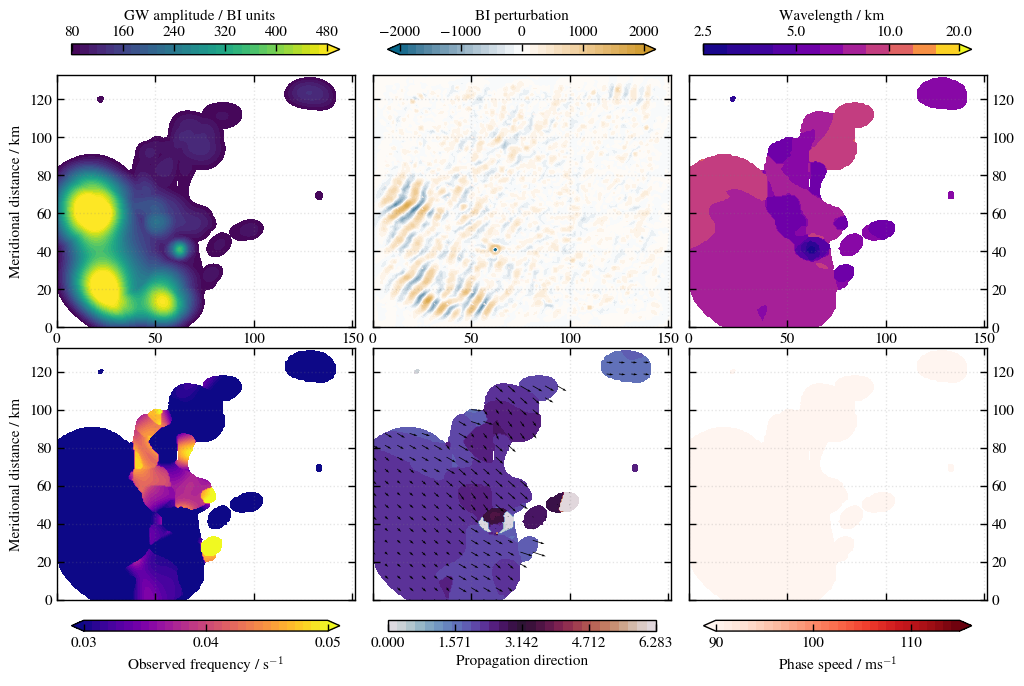

In [6]:
gskw = {"hspace": 0.15, "wspace": 0.06, "width_ratios": [1, 1, 1], "height_ratios": [0.1, 1, 1, 0.1]}
royal=get_cmap().reversed()
BI_lev=np.linspace(-2000,2000,31)

x = np.linspace(0,(nx-1)*dx,nx)*1e-3
y = np.linspace(0,(ny-1)*dy,ny)*1e-3
Y, X = np.meshgrid(y,x)
step=10

xlab = ['','','','Zonal distance / km','Zonal distance / km','Zonal distance / km']
ylab = ['Meridional distande / km','','','Meridional distance','','']

#for time_index in range(3,nt):
time_index=10
print(time_index/nt*100)
xwt_dict = {'decomposition': ds['XWT_real'].isel(time=time_index).values+1j*ds['XWT_imag'].isel(time=time_index).values, 'period': ds['period'], 'theta': ds['theta']}
A, kx, ky, om = wfp.A_kx_ky_kz(xwt_dict,dt)
lh, th = wfp.kxky_2_lhtheta(kx,ky)

th[A<80]=np.nan
lh[A<80]=np.nan
om[A<80]=np.nan
c=lh*om/2/np.pi

fig, ax=plt.subplots(4,3, figsize=(12,8), gridspec_kw=gskw)
ax[0,0].axis('off')
ax[0,1].axis('off')
ax[0,2].axis('off')
ax[3,0].axis('off')
ax[3,1].axis('off')
ax[3,2].axis('off')


plot_amp = ax[1,0].contourf(y,x,A,cmap='viridis',levels=np.linspace(80,480,31),extend='max')
cbar = fig.colorbar(plot_amp, ax=ax[0,0], location='top', ticks=[80,160,240,320,400,480], fraction=1, shrink=0.9, extend='both',label='GW amplitude / BI units', aspect=25)
ax[1,0].set_ylabel('Meridional distance / km')
ax[1,0].grid()

plot_signal = ax[1,1].contourf(y,x,signal[:,:,time_index].T,cmap=royal,levels=BI_lev,extend='both')
ax[1,1].tick_params(which='both', labelleft=False)
cbar = fig.colorbar(plot_signal, ax=ax[0,1], location='top', ticks=[-2000,-1000,0,1000,2000], fraction=1, shrink=0.9, extend='both',label='BI perturbation', aspect=25)
ax[1,1].quiver(Y[::step,::step],X[::step,::step],c[::step,::step]*np.sin(th[::step,::step]),c[::step,::step]*np.cos(th[::step,::step]),c[::step,::step],cmap='Reds',scale=3000,width=0.004,clim=(90,115))
ax[1,1].grid()

plot_lh = ax[1,2].contourf(y,x,lh*1e-3,cmap='plasma',levels=cwt_result['period'][cwt_result['period']<20_000]*1e-3,extend='max')
ax[1,2].tick_params(which='both', labelleft=False, labelright=True)
cbar = fig.colorbar(plot_lh, ax=ax[0,2], location='top', ticks=[2.5,5,10,20], fraction=1, shrink=0.9, extend='both',label='Wavelength / km', aspect=25)
ax[1,2].grid()

plot_om = ax[2,0].contourf(y,x,om,cmap='plasma',levels=np.linspace(0.03,0.05,31),extend='both')
ax[2,0].tick_params(which='both', labelbottom=False)
cbar = fig.colorbar(plot_om, ax=ax[3,0], location='bottom', ticks=[0.03,0.04,0.05], fraction=1, shrink=0.9, extend='both',label='Observed frequency / s$^{-1}$', aspect=25)
ax[2,0].set_ylabel('Meridional distance / km')
ax[2,0].grid()

plot_th = ax[2,1].contourf(y,x,th,cmap='twilight',levels=np.linspace(0,2*np.pi,30))
cbar = fig.colorbar(plot_th, ax=ax[3,1], location='bottom', ticks=[0,np.pi/2,np.pi,3/2*np.pi,2*np.pi], fraction=1, shrink=0.9, extend='both',label='Propagation direction', aspect=25)
ax[2,1].quiver(Y[::step,::step],X[::step,::step],c[::step,::step]*np.sin(th[::step,::step]),c[::step,::step]*np.cos(th[::step,::step]))
ax[2,1].tick_params(which='both', labelbottom=False, labelleft=False)
ax[2,1].grid()

plot_c = ax[2,2].contourf(y,x,c,cmap='Reds',levels=np.linspace(90,115,31),extend='both')
cbar = fig.colorbar(plot_c, ax=ax[3,2], location='bottom', ticks=[90,100,110], fraction=1, shrink=0.9, extend='both',label='Phase speed / ms$^{-1}$', aspect=25)
ax[2,2].tick_params(which='both', labelbottom=False, labelleft=False, labelright=True)
ax[2,2].grid()
#plt.savefig('./fast_wave/gary_'+str(time_index).zfill(2)+'.png', dpi=120, facecolor="w", edgecolor="w")#, bbox_inches="tight")
#plt.close()

In [11]:
import os
import moviepy.video.io.ImageSequenceClip

image_folder = './medium_wave/'
fps = 15

image_files = [
    os.path.join(image_folder, img)
    for img in os.listdir(image_folder)
    if img.endswith(".png")
]
image_files.sort()
clip = moviepy.video.io.ImageSequenceClip.ImageSequenceClip(image_files, fps=fps)
clip.write_videofile("medium_wave_analysis.mp4")

Moviepy - Building video medium_wave_analysis.mp4.
Moviepy - Writing video medium_wave_analysis.mp4



Moviepy - Done !
Moviepy - video ready medium_wave_analysis.mp4


In [49]:
np.nanpercentile(om,[0,5,10,50,90,95,100])

array([0.02811875, 0.03450126, 0.03597934, 0.04140979, 0.04607228,
       0.04753889, 0.05082166])

In [5]:
XWT_real = np.zeros_like(ds['decomposition_real'].values)
XWT_imag = np.zeros_like(ds['decomposition_imag'].values)

for i, step in enumerate(ds.time.isel(time=slice(0,-1))):
    
    XWT_real[:,:,:,:,i] = ds['decomposition_real'].isel(time=i)*ds['decomposition_real'].isel(time=i+1)+ds['decomposition_imag'].isel(time=i)*ds['decomposition_imag'].isel(time=i+1)  
    XWT_imag[:,:,:,:,i] = ds['decomposition_imag'].isel(time=i)*ds['decomposition_real'].isel(time=i+1)-ds['decomposition_real'].isel(time=i)*ds['decomposition_imag'].isel(time=i+1)

XWT_real_xr = xr.DataArray(
    XWT_real,
    dims=("period", "theta", "x", "y", "time"),
    coords={"x": ds['x'].values, "y": ds['y'].values, "time": ds['time'], "period": ds['period'], "theta": ds['theta']},
    )
XWT_imag_xr = xr.DataArray(
    XWT_imag,
    dims=("period", "theta", "x", "y", "time"),
    coords={"x": ds['x'].values, "y": ds['y'].values, "time": ds['time'], "scale": ds['period'], "theta": ds['theta']},
    )

ds['XWT_real'] = XWT_real_xr
ds['XWT_imag'] = XWT_imag_xr

In [ ]:
ds_read.to_netcdf(path="/project/meteo/work/Robert.Reichert/data/AMTM/Rio_Grande/2018/201806/20180616_CWTs/2D_XWT_08UTC.nc")

/scratch-local/slurm-job-tmp-11043891/ipykernel_241/3732910000.py:1: SerializationWarning: saving variable time with floating point data as an integer dtype without any _FillValue to use for NaNs
  ds_read.to_netcdf(path="/project/meteo/work/Robert.Reichert/data/AMTM/Rio_Grande/2018/201806/20180616_CWTs/2D_XWT_08UTC.nc")
